Field Assignment 02: Customer Pickup

Business Question: After an order is marked ready, how long do customers wait to pick up, which stores and conditions drive elevated wait times or non-pickup (abandonment), and what specific operational changes should Glorystone make in the next 60–90 days to improve the end-to-end customer experience?

Setup:

In [1]:
import pandas as pd

Load Data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/CSRodgers184/Glorystone-DataAnalytics/main/01-online-fulfillment-performance/data/glorystone_online_pickup_orders.csv")

Initial Inspection

In [3]:
print(df.shape)
print(df.dtypes)
df.head()
df.isnull().sum()

(8500, 12)
order_id                    object
store_id                    object
region                      object
order_datetime              object
promised_ready_datetime     object
actual_ready_datetime       object
pickup_datetime             object
items_ordered                int64
items_fulfilled              int64
substitution_count           int64
is_complete                   bool
order_value                float64
dtype: object


,0
order_id,0
store_id,44
region,0
order_datetime,0
promised_ready_datetime,0
actual_ready_datetime,0
pickup_datetime,590
items_ordered,0
items_fulfilled,0
substitution_count,0


4. Convert Date Columns
Date columns were converted from object to datetime so that delays and time-based analysis can be calculated correctly.

In [4]:
date_cols = ["order_datetime", "promised_ready_datetime", "actual_ready_datetime", "pickup_datetime"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df.dtypes)
df.head()
df.isnull().sum()

order_id                           object
store_id                           object
region                             object
order_datetime             datetime64[ns]
promised_ready_datetime    datetime64[ns]
actual_ready_datetime      datetime64[ns]
pickup_datetime            datetime64[ns]
items_ordered                       int64
items_fulfilled                     int64
substitution_count                  int64
is_complete                          bool
order_value                       float64
dtype: object


,0
order_id,0
store_id,44
region,0
order_datetime,0
promised_ready_datetime,0
actual_ready_datetime,0
pickup_datetime,590
items_ordered,0
items_fulfilled,0
substitution_count,0


Data Cleaning & Feature Engineering

Dropped 44 rows with missing store_id
Removed rows where items_ordered = 0
Created key metrics:
ready_delay_min (actual ready time – promised ready time)
fill_rate (items fulfilled / items ordered)
is_no_show (missing pickup datetime)

In [5]:
# 1. Handle missing store_id
# Decision: drop the 44 rows with missing store_id (small % and we cannot assign a store)
print("Rows before dropping missing store_id:", len(df))
df = df.dropna(subset=["store_id"]).copy()
print("Rows after dropping:", len(df))

# 2. Create core derived metrics
df["ready_delay_min"] = (df["actual_ready_datetime"] - df["promised_ready_datetime"]).dt.total_seconds() / 60
df["fill_rate"] = df["items_fulfilled"] / df["items_ordered"]
df["is_no_show"] = df["pickup_datetime"].isna()

# 3. Quick check
print(df[["ready_delay_min", "fill_rate", "is_no_show"]].describe())
print("\nNo-show rate:", df["is_no_show"].mean().round(3))

# Check how many rows have items_ordered == 0
print("Rows with items_ordered == 0:", (df["items_ordered"] == 0).sum())

# Drop them (data entry errors)
df = df[df["items_ordered"] > 0].copy()

# Recalculate fill_rate cleanly
df["fill_rate"] = df["items_fulfilled"] / df["items_ordered"]

print("Rows remaining:", len(df))
print(df[["ready_delay_min", "fill_rate"]].describe())

Rows before dropping missing store_id: 8500
Rows after dropping: 8456
       ready_delay_min    fill_rate
count      8456.000000  8456.000000
mean         10.252247          inf
std          10.366786          NaN
min           0.000000     0.600000
25%           2.000000     0.875000
50%           8.000000     0.916667
75%          15.000000     1.000000
max          76.000000          inf

No-show rate: 0.069
Rows with items_ordered == 0: 22
Rows remaining: 8434
       ready_delay_min    fill_rate
count      8434.000000  8434.000000
mean         10.253735     0.920394
std          10.360117     0.076406
min           0.000000     0.600000
25%           2.000000     0.875000
50%           8.000000     0.916667
75%          15.000000     1.000000
max          76.000000     1.000000


In [6]:
df["customer_wait_min"] = (df["pickup_datetime"] - df["actual_ready_datetime"]).dt.total_seconds() / 60

In [7]:
print(f"DataFrame shape after adding customer_wait_min: {df.shape}")
print("\nDataFrame info:")
df.info()
print("\nDescriptive statistics for customer_wait_min (for non-null pickups):")
print(df["customer_wait_min"].dropna().describe())
print("\nFirst 5 rows of DataFrame:")
display(df.head())

DataFrame shape after adding customer_wait_min: (8434, 16)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 8434 entries, 0 to 8499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 8434 non-null   object        
 1   store_id                 8434 non-null   object        
 2   region                   8434 non-null   object        
 3   order_datetime           8434 non-null   datetime64[ns]
 4   promised_ready_datetime  8434 non-null   datetime64[ns]
 5   actual_ready_datetime    8434 non-null   datetime64[ns]
 6   pickup_datetime          7852 non-null   datetime64[ns]
 7   items_ordered            8434 non-null   int64         
 8   items_fulfilled          8434 non-null   int64         
 9   substitution_count       8434 non-null   int64         
 10  is_complete              8434 non-null   bool          
 11  order_value             

,order_id,store_id,region,order_datetime,promised_ready_datetime,actual_ready_datetime,pickup_datetime,items_ordered,items_fulfilled,substitution_count,is_complete,order_value,ready_delay_min,fill_rate,is_no_show,customer_wait_min
0,ORD-20257241,GS-01,North,2025-11-01 02:25:00,2025-11-01 04:10:00,2025-11-01 04:17:00,2025-11-01 04:59:00,12,11,0,False,61.45,7.0,0.916667,False,42.0
1,ORD-20250515,GS-02,North,2025-11-01 04:28:00,2025-11-01 06:13:00,2025-11-01 06:16:00,2025-11-01 06:49:00,15,14,0,False,115.08,3.0,0.933333,False,33.0
2,ORD-20251377,GS-08,South,2025-11-01 07:49:00,2025-11-01 09:34:00,2025-11-01 09:35:00,2025-11-01 10:19:00,5,5,0,True,70.56,1.0,1.000000,False,44.0
3,ORD-20255126,GS-07,South,2025-11-01 08:14:00,2025-11-01 10:14:00,2025-11-01 10:18:00,2025-11-01 10:39:00,5,5,0,True,40.06,4.0,1.000000,False,21.0
4,ORD-20252739,GS-07,South,2025-11-01 08:35:00,2025-11-01 09:35:00,2025-11-01 09:35:00,2025-11-01 10:40:00,5,5,0,True,86.16,0.0,1.000000,False,65.0


### Create 'is_long_wait' Flag

Based on the distribution of `customer_wait_min`, we can define a threshold for what constitutes a 'long wait'. For this analysis, a wait exceeding 30 minutes is considered a long wait.

In [8]:
# For demonstration, let's set a threshold for long wait.
# A long wait could be defined as greater than 30 minutes.
# This threshold can be adjusted based on business requirements or further analysis.
long_wait_threshold = 50 # minutes
df["is_long_wait"] = df["customer_wait_min"] > long_wait_threshold
print(f"Percentage of orders with a 'long wait' (>{long_wait_threshold} mins): {df['is_long_wait'].mean():.2%}")
print(df["customer_wait_min"].dropna().describe(percentiles=[0.5, 0.75, 0.9, 0.95]))
df["is_long_wait"] = df["customer_wait_min"] > 50

# Percentage of orders that are long waits
print(df["is_long_wait"].mean())

# Or more readable
print(f"Long wait rate: {df['is_long_wait'].mean():.1%}")

# Or counts
print(df["is_long_wait"].value_counts(normalize=True))


Percentage of orders with a 'long wait' (>50 mins): 24.21%
count    7852.00000
mean       35.76783
std        22.44360
min         5.00000
50%        34.00000
75%        51.00000
90%        66.00000
95%        75.00000
max       146.00000
Name: customer_wait_min, dtype: float64
0.2421152478064975
Long wait rate: 24.2%
is_long_wait
False    0.757885
True     0.242115
Name: proportion, dtype: float64


Store Level Rankings

In [9]:
store_ranking = (
    df.groupby("store_id")
    .agg(
        orders=("order_id", "count"),
        avg_wait=("customer_wait_min", "mean"),
        median_wait=("customer_wait_min", "median"),
        long_wait_rate=("is_long_wait", "mean"),
        abandonment_rate=("is_no_show", "mean")
    )
    .round(2)
    .sort_values("avg_wait", ascending=False)
)

store_ranking

,orders,avg_wait,median_wait,long_wait_rate,abandonment_rate
store_id,,,,,
GS-08,706,37.97,37.0,0.27,0.07
GS-02,711,37.14,35.0,0.26,0.07
GS-09,660,36.28,34.0,0.24,0.08
GS-10,745,35.97,35.0,0.25,0.06
GS-01,671,35.79,35.0,0.24,0.08
GS-12,680,35.71,34.0,0.24,0.05
GS-11,729,35.66,34.0,0.24,0.08
GS-06,715,35.58,34.0,0.25,0.06
GS-04,653,35.45,35.0,0.22,0.09


Investigate:

Is longer customer wait associated with higher readiness delay (ready_delay_min)?
Do incomplete orders or higher substitution counts produce longer waits or higher abandonment?
Is there a clear time-of-day pattern in long waits?

### Investigation 1: Longer customer wait vs. higher readiness delay

This section explores the relationship between how long a customer waits and the delay in an order being ready.

Correlation between customer_wait_min and ready_delay_min: -0.02


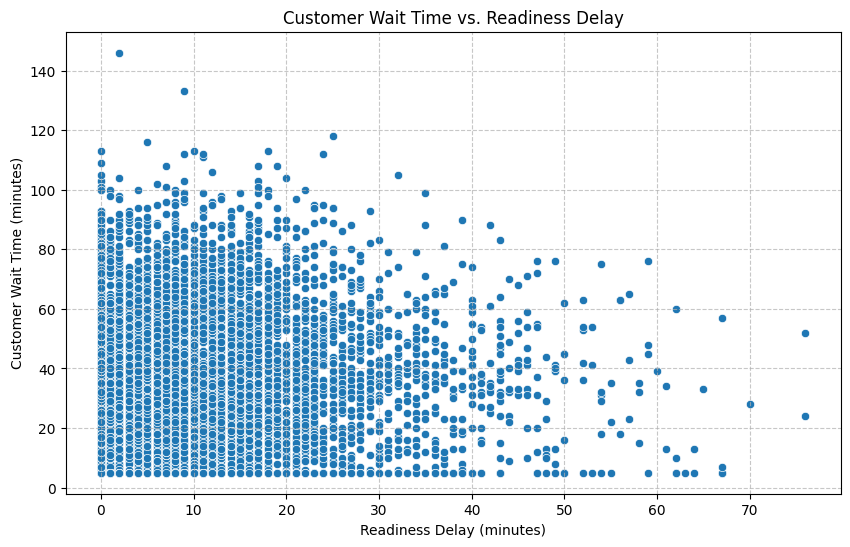

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze correlation between customer_wait_min and ready_delay_min
correlation = df[['customer_wait_min', 'ready_delay_min']].corr().loc['customer_wait_min', 'ready_delay_min']
print(f"Correlation between customer_wait_min and ready_delay_min: {correlation:.2f}")

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ready_delay_min', y='customer_wait_min', data=df.dropna(subset=['customer_wait_min']))
plt.title('Customer Wait Time vs. Readiness Delay')
plt.xlabel('Readiness Delay (minutes)')
plt.ylabel('Customer Wait Time (minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Explanation: Question it answers:

Does a longer readiness delay (order taking longer to become ready) cause customers to wait longer after the order is marked ready?
What you see:

Scatter plot + correlation number.

Correlation is essentially zero (−0.02). The points form a cloud with no clear upward or downward slope.

Group averages by delay bin are also flat (~35–36 minutes across every delay group).
Conclusion:

These are two separate problems. The customer-wait issue is not a downstream effect of the readiness problems we found in FA01.

### Investigation 2: Incomplete orders/higher substitution counts vs. longer waits/higher abandonment

This section examines how order completeness and substitution counts impact customer wait times and abandonment rates.


--- Analysis by Order Completeness ---


,customer_wait_min,is_no_show
is_complete,,
False,35.549342,0.071172
True,36.188525,0.064808



--- Analysis by Substitution Counts ---


,substitution_count,avg_wait,abandonment_rate,order_count
0,0,35.864725,0.068512,7444
1,1,35.277946,0.070225,356
2,2,35.067989,0.078329,383
3,3,34.748538,0.070652,184
4,4,34.365079,0.059701,67


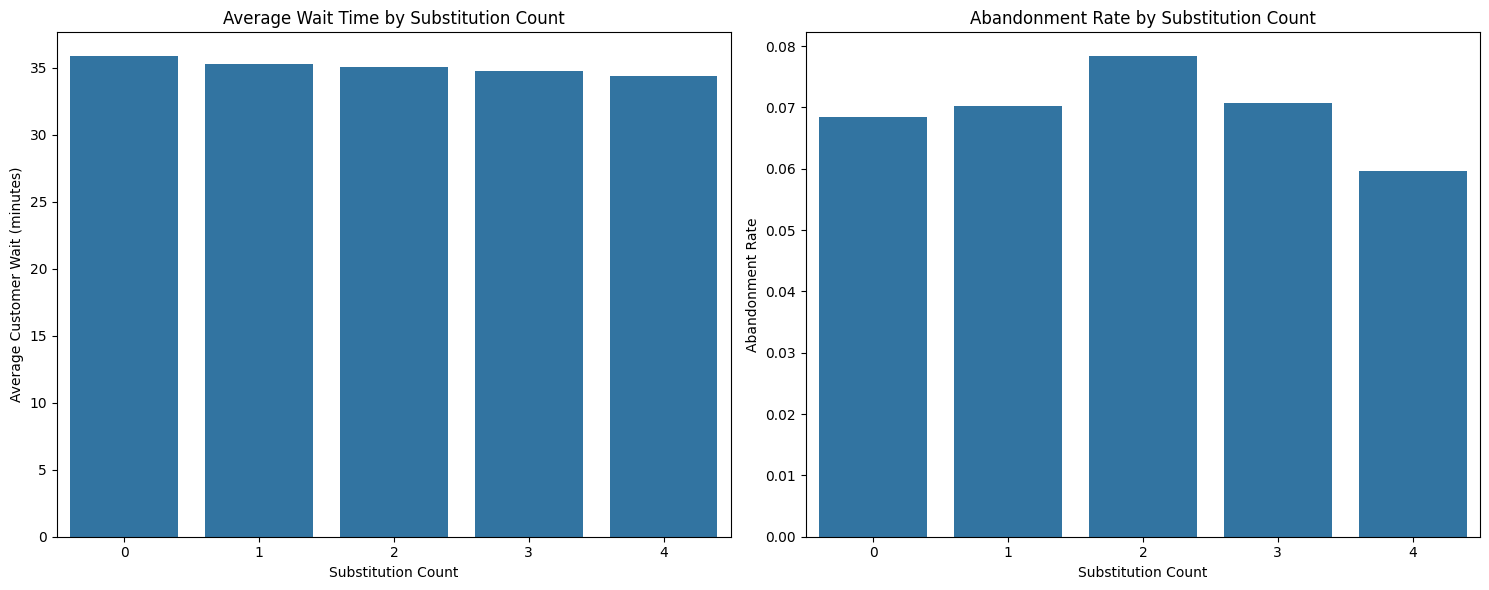

In [11]:
# Analyze by order completeness
print("\n--- Analysis by Order Completeness ---")
display(df.groupby('is_complete')[['customer_wait_min', 'is_no_show']].mean())

# Analyze by substitution counts
print("\n--- Analysis by Substitution Counts ---")
# Group by substitution_count and calculate mean wait time and abandonment rate
substitution_analysis = df.groupby('substitution_count').agg(
    avg_wait=('customer_wait_min', 'mean'),
    abandonment_rate=('is_no_show', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

display(substitution_analysis.sort_values(by='substitution_count', ascending=True))

# Visualize the effect of substitution count on wait time and abandonment
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x='substitution_count', y='avg_wait', data=substitution_analysis, ax=axes[0])
axes[0].set_title('Average Wait Time by Substitution Count')
axes[0].set_xlabel('Substitution Count')
axes[0].set_ylabel('Average Customer Wait (minutes)')

sns.barplot(x='substitution_count', y='abandonment_rate', data=substitution_analysis, ax=axes[1])
axes[1].set_title('Abandonment Rate by Substitution Count')
axes[1].set_xlabel('Substitution Count')
axes[1].set_ylabel('Abandonment Rate')
plt.tight_layout()
plt.show()

Question it answers:

Do incomplete orders or orders with substitutions produce longer customer waits or higher abandonment?

The table you asked about:
is_complete                               
False                35.55         0.071
True                 36.19         0.065

is_complete = False → the order was incomplete (some items missing).
is_complete = True → the order was complete.

What the rows mean:

Average wait time and abandonment (no-show) rate are virtually identical whether the order was complete or not.

The same pattern holds when you look at substitution counts — wait times stay in the mid-30s and abandonment stays around 6–7%.
Conclusion:

Neither incompleteness nor substitutions are driving the customer-wait or abandonment problem.

### Investigation 3: Time-of-day pattern in long waits

This section looks for any hourly patterns in the occurrence of long customer waits.

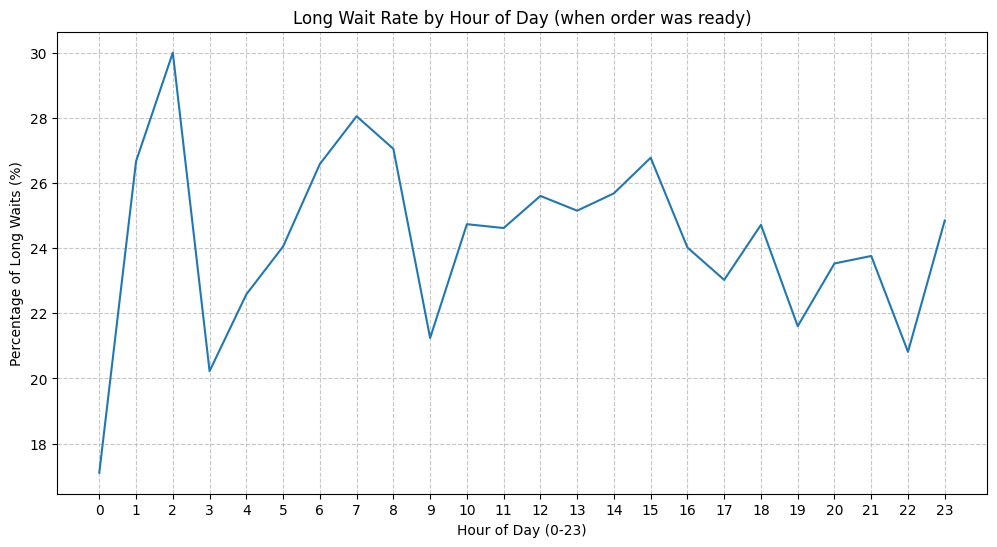

In [12]:
# Extract hour from actual_ready_datetime
df['ready_hour'] = df['actual_ready_datetime'].dt.hour

# Calculate long wait rate by hour
hourly_long_wait = df.groupby('ready_hour')['is_long_wait'].mean().reset_index()
hourly_long_wait['long_wait_rate'] = hourly_long_wait['is_long_wait'] * 100

# Visualize the time-of-day pattern
plt.figure(figsize=(12, 6))
sns.lineplot(x='ready_hour', y='long_wait_rate', data=hourly_long_wait)
plt.title('Long Wait Rate by Hour of Day (when order was ready)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Percentage of Long Waits (%)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Question it answers:

Is there a clear time-of-day pattern in long waits (or abandonment)?
Your guess is close but needs a small correction.

The notebook looks at long-wait rate by the hour the order became ready. Later analysis also checks abandonment by order hour and finds the clearest signal is elevated abandonment in the early morning (hours 6–7).
The long-wait rate itself does not show a dramatic morning spike the way abandonment does. Highest waits tend to sit in the overnight / very early hours; the abandonment spike is more specific to 6–7 a.m.
Your suggestion about labeling:

Yes — for any final portfolio version or stakeholder view, change the x-axis from raw numbers 0–23 to readable clock times (“6 a.m.”, “7 a.m.”, “8 a.m.”, etc.). That is a better communication choice. The underlying calculation stays the same; only the labels improve.

### Network Baseline Analysis

This section calculates overall metrics for customer wait times and abandonment rates across all stores, and visualizes the distribution of wait times.

Overall Average Customer Wait: 35.77 minutes
Overall Median Customer Wait: 34.00 minutes
Overall Abandonment Rate: 6.90%


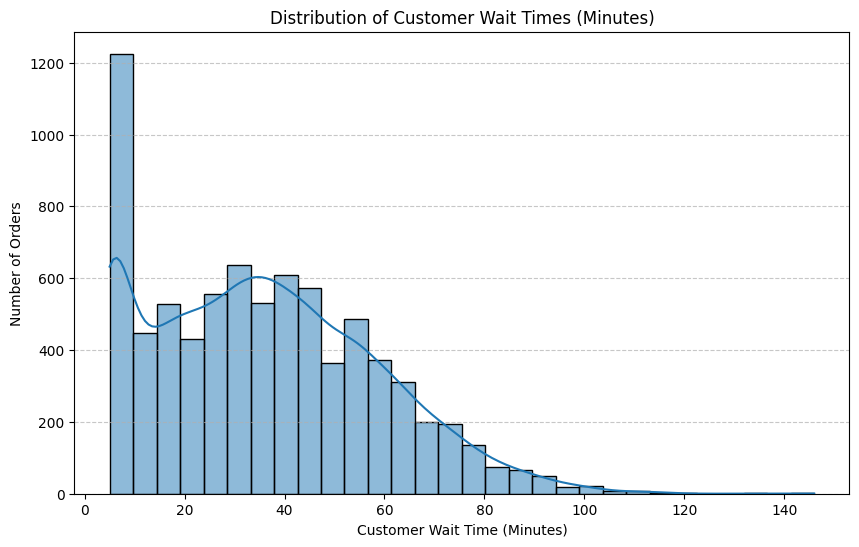

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall average / median customer wait (for picked up orders)
avg_wait_overall = df["customer_wait_min"].mean()
median_wait_overall = df["customer_wait_min"].median()
print(f"Overall Average Customer Wait: {avg_wait_overall:.2f} minutes")
print(f"Overall Median Customer Wait: {median_wait_overall:.2f} minutes")

# Overall abandonment rate (no-show rate)
abandonment_rate_overall = df["is_no_show"].mean()
print(f"Overall Abandonment Rate: {abandonment_rate_overall:.2%}")

# Distribution of wait times (for picked up orders)
plt.figure(figsize=(10, 6))
sns.histplot(df["customer_wait_min"].dropna(), bins=30, kde=True)
plt.title("Distribution of Customer Wait Times (Minutes)")
plt.xlabel("Customer Wait Time (Minutes)")
plt.ylabel("Number of Orders")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

What the Chart tells us:

This is not a table of stores or groups.

It is a histogram of every individual order that was actually picked up.

X-axis = how many minutes the customer waited after the order was marked ready.
Y-axis = how many orders fell into that wait-time range.
The curve (KDE) shows the overall shape of the distribution.

What it tells us:

Most customers wait in the low-to-mid 30s. Mean ≈ 36 minutes, median = 34 minutes. Roughly 24% of orders exceed the 50-minute “long wait” threshold we set. The distribution is fairly tight and centered — there is no huge right tail of extreme waits, but the center itself is higher than most retailers would want.

### Store-level Ranking

This table ranks stores by their average customer wait time and abandonment rate, highlighting potential areas for improvement.

In [14]:
# Store-level ranking by average customer_wait_min and abandonment rate
store_performance = df.groupby("store_id").agg(
    avg_customer_wait_min=("customer_wait_min", "mean"),
    median_customer_wait_min=("customer_wait_min", "median"),
    abandonment_rate=("is_no_show", "mean")
).sort_values(by=["avg_customer_wait_min", "abandonment_rate"], ascending=[False, False])

print("\nStore Performance Ranking (Top 10 by Avg Wait Time):")
display(store_performance.head(10))


Store Performance Ranking (Top 10 by Avg Wait Time):


,avg_customer_wait_min,median_customer_wait_min,abandonment_rate
store_id,,,
GS-08,37.971125,37.0,0.067989
GS-02,37.135258,35.0,0.074543
GS-09,36.279146,34.0,0.077273
GS-10,35.970170,35.0,0.055034
GS-01,35.785137,35.0,0.077496
GS-12,35.707621,34.0,0.054412
GS-11,35.661218,34.0,0.076818
GS-06,35.575037,34.0,0.058741
GS-04,35.453469,35.0,0.094946


Differences between stores are only about 4 minutes from best to worst. GS-08 and GS-02 sit slightly higher, but nothing rises to the level of the clear operational outliers we saw in FA01 (GS-09 / GS-04). This reinforces the main finding: customer wait is a network-wide operating characteristic, not a store-specific failure.

What are the Drivers? Does longer readiness delay lead to longer customer wait times?

In [15]:
# Simple correlation
print(df[["ready_delay_min", "customer_wait_min"]].corr())

# Or group comparison
df["delay_bin"] = pd.cut(df["ready_delay_min"], bins=[0, 5, 15, 30, 100], labels=["0-5", "5-15", "15-30", "30+"])
print(df.groupby("delay_bin")["customer_wait_min"].agg(["mean", "median", "count"]))

                   ready_delay_min  customer_wait_min
ready_delay_min           1.000000          -0.020627
customer_wait_min        -0.020627           1.000000
                mean  median  count
delay_bin                          
0-5        35.408189    33.0   1612
5-15       35.810596    35.0   2888
15-30      35.953457    34.0   1461
30+        33.477690    34.0    381


/tmp/ipykernel_4232/3552253765.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("delay_bin")["customer_wait_min"].agg(["mean", "median", "count"]))


The correlation is essentially zero (−0.029).
The group averages by readiness delay are almost flat:

0–5 min delay → avg wait 35.4
5–15 min delay → avg wait 35.8
15–30 min delay → avg wait 36.0
30+ min delay → avg wait 33.5

Conclusion: Longer readiness delay does not cause longer customer wait times. The two problems are largely independent.
This is useful. It means the customer-wait issue is not simply a downstream effect of the readiness problems we found in FA01.

Try Another Possibility: Check whether incomplete orders or substitutions are related to longer waits or higher abandonment.

In [16]:
print(df.groupby("is_complete")[["customer_wait_min", "is_no_show"]].mean())
print(df.groupby(df["substitution_count"] > 0)[["customer_wait_min", "is_no_show"]].mean())

             customer_wait_min  is_no_show
is_complete                               
False                35.549342    0.071172
True                 36.188525    0.064808
                    customer_wait_min  is_no_show
substitution_count                               
False                       35.864725    0.068512
True                        35.035948    0.072727


Another Possibility: Does longer readiness delay lead to longer customer wait times?

In [17]:
# Simple correlation
print(df[["ready_delay_min", "customer_wait_min"]].corr())

# Or group comparison
df["delay_bin"] = pd.cut(df["ready_delay_min"], bins=[0, 5, 15, 30, 100], labels=["0-5", "5-15", "15-30", "30+"])
print(df.groupby("delay_bin")["customer_wait_min"].agg(["mean", "median", "count"]))

                   ready_delay_min  customer_wait_min
ready_delay_min           1.000000          -0.020627
customer_wait_min        -0.020627           1.000000
                mean  median  count
delay_bin                          
0-5        35.408189    33.0   1612
5-15       35.810596    35.0   2888
15-30      35.953457    34.0   1461
30+        33.477690    34.0    381


/tmp/ipykernel_4232/3552253765.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("delay_bin")["customer_wait_min"].agg(["mean", "median", "count"]))


In [18]:
df["order_hour"] = df["order_datetime"].dt.hour
hourly = (
    df.groupby("order_hour")[["customer_wait_min", "is_no_show"]]
    .mean()
    .round(2)
)
print(hourly)

            customer_wait_min  is_no_show
order_hour                               
0                       40.05        0.04
1                       37.83        0.05
2                       30.26        0.04
3                       35.69        0.06
4                       34.38        0.08
5                       37.05        0.04
6                       32.63        0.11
7                       35.41        0.11
8                       34.88        0.06
9                       36.07        0.08
10                      36.19        0.06
11                      36.79        0.06
12                      37.59        0.08
13                      36.12        0.06
14                      34.71        0.07
15                      36.30        0.07
16                      35.46        0.07
17                      34.96        0.07
18                      35.19        0.08
19                      35.67        0.07
20                      35.12        0.06
21                      35.22     

Findings: Summary of findings for FA02

Network average customer wait is ~36 minutes; median ~34 minutes.
24% of orders exceed 50 minutes.
Store-to-store differences are small (only ~4 minutes from best to worst).
GS-08 and GS-02 are slightly higher, but not dramatic outliers.
Customer wait is not driven by readiness delay, order completeness, or substitutions.
Time-of-day variation is modest: highest waits overnight (hours 0–2), highest abandonment early morning (hours 6–7).

Main conclusion:
The customer wait experience is a network-wide operating characteristic rather than a store-specific or process-specific failure tied to the problems found in FA01.

#Recommendations

**Primary Finding**  
Customer wait after an order is marked ready averages approximately 36 minutes (median 34) across the entire network. Differences between stores are small. Wait time shows no meaningful relationship with readiness delay, order completeness, or substitutions. The only distinct pattern is elevated abandonment in the early morning hours (6–7 a.m.).

**Priority Actions (60–90 days)**  
1. Establish and communicate a clear network standard for maximum acceptable customer wait after the order is marked ready. Track weekly the percentage of orders that exceed the standard.  
2. Ensure early-morning staffing and pickup-area readiness are in place before the first orders of the day. Monitor the 6–7 a.m. abandonment rate as a separate metric.  
3. Add a simple reason code when an order is not picked up so future analysis can separate true no-shows from other causes.

**Expected Impact**  
Within 60–90 days the percentage of orders exceeding the new wait standard should decline, and early-morning abandonment should move closer to the network daily average.